In [ ]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import ListedColormap

from utils import *

from scipy import stats
from statsmodels.stats.multitest import multipletests

obs_labels_path = '/jukebox/falkner/Jorge/Dexter_results/all_obs_xpo_pred_dict_v1_062625.pkl'
with open(obs_labels_path, "rb") as f:
    obs_data_dict = pickle.load(f)

with open(attack_labels_path, "rb") as f:
    beh_data_dict = pickle.load(f)
    
trial_metadata_path = "/usr/people/tt1131/projects/social_dojo_observer/data/trial_filtering_metadata.pickle"

with open(trial_metadata_path, "rb") as f:
    trial_metadata = pickle.load(f)
    
matched_data_path = "/usr/people/tt1131/projects/social_dojo_observer/data/attention_shifts.pickle"

with open(matched_data_path, "rb") as f:
    mouse_matches_dict = pickle.load(f)

setup_plot_style()

def process_behavior_segments(match_indices, match_info, 
                              shifts, all_predictions, 
                              bad_session_indices, mouse_id):
    beh_segments = []
    beh_segments_smpl = []
    matched_shifts = []
    full_to_match_indices = {}
    matched_count = 0
    for idx, (match_day_session, match_info_indices, shift) in enumerate(zip(match_indices, match_info, shifts)):
        day_idx, session_idx = match_day_session
        session_label = f'{mouse_id}_d{day_idx}_obs_t{session_idx}'
        if session_label in bad_session_indices:
            full_to_match_indices[idx] = np.nan
            continue
        
        session_labels = all_predictions[session_label]
        if match_info_indices[-1] < len(session_labels):
            pred_window = session_labels[match_info_indices]
            beh_segments.append(pred_window)
            beh_segments_smpl.append(label_to_categories(pred_window))
            matched_shifts.append(shift)
            full_to_match_indices[idx] = matched_count
            matched_count += 1
        else:
            full_to_match_indices[idx] = np.nan
            
    return np.array(beh_segments), np.array(beh_segments_smpl), np.array(matched_shifts), full_to_match_indices

def shift_behavior_segments(behavior_segments, behavior_shifts, window_size):
    behavior_segments_shifted = []
    bad_indices = []
    for idx, (behavior_seg, shift) in enumerate(zip(behavior_segments, behavior_shifts)):
        if abs(shift) > 100:
            bad_indices.append(idx)
            continue
        if shift < 0:
            padded = np.pad(behavior_seg, (-shift, 0), mode='constant', constant_values=0)
            behavior_segments_shifted.append(padded[:window_size])
        else:
            padded = np.pad(behavior_seg, (0, shift), mode='constant', constant_values=0)
            behavior_segments_shifted.append(padded[shift:])
    return np.array(behavior_segments_shifted), np.array(bad_indices)

def compare_arrays_with_fdr(x, x_shifted, column_labels=None, alpha=0.05):
    """
    Compare corresponding columns between two arrays using t-tests with FDR correction.
    
    Parameters
    ----------
    x : np.ndarray
        Array of shape (n_trials, n_columns)
    x_shifted : np.ndarray
        Array of shape (n_trials, n_columns) to compare against x
    column_labels : list, optional
        Labels for each column. If None, uses indices.
    alpha : float
        Significance level for FDR correction
        
    Returns
    -------
    results : dict
        Dictionary containing test statistics, p-values, and corrected p-values
    """
    assert x.shape == x_shifted.shape, "Arrays must have the same shape"
    n_trials, n_columns = x.shape
    
    if column_labels is None:
        column_labels = [f"Column_{i}" for i in range(n_columns)]
    
    # Perform t-tests for each column
    t_stats = []
    p_values = []
    
    print("Paired t-tests for each column:")
    print("-" * 60)
    for i, label in enumerate(column_labels):
        # Paired t-test (comparing same trials across conditions)
        t_stat, p_val = stats.ttest_rel(x[:, i], x_shifted[:, i])
        t_stats.append(t_stat)
        p_values.append(p_val)
        
        mean_diff = np.mean(x[:, i] - x_shifted[:, i])
        print(f"{label}: t={t_stat:.3f}, p={p_val:.4f}, mean_diff={mean_diff:.4f}")
    
    # Apply FDR correction
    rejected, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    
    # Print corrected results
    print(f"\nFDR-corrected results (α={alpha}):")
    print("-" * 60)
    for label, p_val, p_corr, is_sig, t_stat in zip(
        column_labels, p_values, p_corrected, rejected, t_stats
    ):
        sig_str = "***" if p_corr < 0.001 else ("**" if p_corr < 0.01 else ("*" if p_corr < 0.05 else "ns"))
        print(f"{label}: p={p_val:.4f}, p_corrected={p_corr:.4f}, {sig_str}")
    
    return {
        'column_labels': column_labels,
        't_statistics': t_stats,
        'p_values': p_values,
        'p_corrected': p_corrected,
        'rejected': rejected
    }

In [2]:
mouse_key = 'mouse0'
mouse_id = mouse_to_id_dict[mouse_key]
match_info = mouse_matches_dict[mouse_id]['session_windows']
match_indices = mouse_matches_dict[mouse_id]['session_indices']
shifts = mouse_matches_dict[mouse_id]['shifts']
mapping = mouse_matches_dict[mouse_id]['mapping']
match_info

array([[  459,   460,   461, ...,   936,   937,   938],
       [ 1526,  1527,  1528, ...,  2003,  2004,  2005],
       [ 2830,  2831,  2832, ...,  3307,  3308,  3309],
       ...,
       [ 6846,  6847,  6848, ...,  7323,  7324,  7325],
       [14320, 14321, 14322, ..., 14797, 14798, 14799],
       [18715, 18716, 18717, ..., 19192, 19193, 19194]])

In [3]:
## Okay the next step here is clearer now: we take the behavior traces and see if they match the attention_values/ filtered status
all_predictions = {}
mouse_obs_beh = obs_data_dict[mouse_to_id_dict[mouse_key]]
bad_session_indices = []

for day_idx in np.arange(1, 9):
    for session_idx in np.arange(1, 4):
        session_data = mouse_obs_beh[(mouse_obs_beh['day_id'] == day_idx) & (mouse_obs_beh['session_id'] == session_idx)]
        session_label = f'{mouse_id}_d{day_idx}_obs_t{session_idx}'
        if len(session_data) == 0:
            continue
        
        attack_labels_d_s = beh_data_dict[session_label]['attack labels'].values
        all_predictions[session_label] = session_data['prediction'].values
        diff = len(session_data) - len(attack_labels_d_s)
        if diff < 0: ## This is just to detect bad sessions with no 
            print(f"{mouse_id}, Day {day_idx}, Session {session_idx}, with diff = {diff}")
            all_predictions[f'{mouse_id}_d{day_idx}_obs_t{session_idx}'] = np.full(abs(diff), np.nan)
            bad_session_indices.append(f'{mouse_id}_d{day_idx}_obs_t{session_idx}')
        else:
            all_predictions[f'{mouse_id}_d{day_idx}_obs_t{session_idx}'] = session_data['prediction'].values[diff: ] ## Cropping to same length as attack labels 
len(all_predictions)

30R2, Day 2, Session 1, with diff = -7368
30R2, Day 4, Session 1, with diff = -12375
30R2, Day 8, Session 1, with diff = -1781


24

In [4]:
window_size = 480
beh_segments = []
beh_segments_smpl = []
matched_shifts = []
full_to_match_indices = {}

matched_count = 0
for idx, (match_day_session, match_info_indices, shift) in enumerate(zip(match_indices, match_info, shifts)):
    day_idx, session_idx = match_day_session
    session_label = f'{mouse_id}_d{day_idx}_obs_t{session_idx}'
    if session_label in bad_session_indices:
        full_to_match_indices[idx] = np.nan
        continue
    
    session_labels = all_predictions[session_label]
    if match_info_indices[-1] <= len(session_labels):
        pred_window = session_labels[match_info_indices]
        beh_segments.append(pred_window)
        beh_segments_smpl.append(label_to_categories(pred_window))
        matched_shifts.append(shift)
        full_to_match_indices[idx] = matched_count
        matched_count += 1
    else:
        full_to_match_indices[idx] = np.nan
        print(day_idx, session_idx, idx, match_info_indices[0], match_info_indices[-1], session_labels.shape)

2 2 48 19573 20052 (19708,)
3 1 83 22851 23330 (22991,)
3 2 96 24902 25381 (24917,)
5 2 156 20816 21295 (20957,)
6 2 196 19802 20281 (19976,)
7 1 219 18617 19096 (18649,)


In [ ]:
reverse_mapping = {v: k for k, v in mapping.items()}
reverse_full_to_match_indices = {v: k for k, v in full_to_match_indices.items()}

kept_indices = trial_metadata[mouse_key]['kept_indices']
filtered_indices = trial_metadata[mouse_key]['filtered_indices']
kept_indices[:5], filtered_indices[:5]

([0, 2, 4, 5, 7], [1, 3, 6, 8, 9])

In [ ]:
## We go from original to mapped 
# mapping goes from data to shifted data (but our indices are in shifted data space)

kept_first_map_indices = [reverse_mapping[i] for i in kept_indices]
filtered_first_map_indices = [reverse_mapping[i] for i in filtered_indices]

# Now we are at the first mapping, but then we need to go to second mapping, which is what beahvioral segments we have
# Then we need to go through full_to_match_indices from full to match

kept_second_map_indices = [full_to_match_indices[i] for i in kept_first_map_indices]
filtered_second_map_indices = [full_to_match_indices[i] for i in filtered_first_map_indices]

## ok this is not promising, but we can switch to another way to ask what do the kept
## indices look like

kept_behavior_segments = []
kept_behavior_shifts = []
for idx, kept_idx in enumerate(kept_second_map_indices):
    if np.isnan(kept_idx):
        continue
    kept_behavior_segments.append(beh_segments_smpl[kept_idx])
    kept_behavior_shifts.append(matched_shifts[kept_idx])
        
kept_behavior_segments = np.array(kept_behavior_segments)
kept_behavior_shifts = np.array(kept_behavior_shifts)

filtered_behavior_segments = []
filtered_behavior_indices = []
for idx, filtered_idx in enumerate(filtered_second_map_indices):
    if np.isnan(filtered_idx):
        continue
    filtered_behavior_segments.append(beh_segments_smpl[filtered_idx])
    filtered_behavior_indices.append(matched_shifts[filtered_idx])
    
filtered_behavior_segments = np.array(filtered_behavior_segments)
filtered_behavior_indices = np.array(filtered_behavior_indices)
print(f'len(kept_behavior_shifts), len(filtered_behavior_indices) = {len(kept_behavior_shifts)}, {len(filtered_behavior_indices)}')

len(kept_behavior_shifts), len(filtered_behavior_indices) = 136, 88


In [12]:
kept_behavior_segments_shifted = []
bad_indices = []
for idx, (behavior_seg, shift) in enumerate(zip(kept_behavior_segments, kept_behavior_shifts)):
    if abs(shift) > 100:
        bad_indices.append(idx)
        continue
    if shift < 0:
        padded = np.pad(behavior_seg, (-shift, 0), mode='constant', constant_values=0)
        kept_behavior_segments_shifted.append(padded[:window_size])
    else:
        padded = np.pad(behavior_seg, (0, shift), mode='constant', constant_values=0)
        kept_behavior_segments_shifted.append(padded[shift:])
kept_behavior_segments_shifted = np.array(kept_behavior_segments_shifted)

if len(bad_indices) > 0:
    kept_behavior_segments_cleaned = np.delete(kept_behavior_segments, bad_indices, axis = 0)
    kept_behavior_shifts_cleaned = np.delete(kept_behavior_shifts, bad_indices, axis = 0)

pos_shifts_indices = np.where(kept_behavior_shifts > 0)[0]
neg_shifts_indices = np.where(kept_behavior_shifts < 0)[0]
no_shifts_indices = np.where(kept_behavior_shifts == 0)[0]

pos_shifts = len(pos_shifts_indices) / len(kept_behavior_shifts)
neg_shifts = len(neg_shifts_indices) / len(kept_behavior_shifts)
no_shifts = len(no_shifts_indices) / len(kept_behavior_shifts)

print(f'pos_shifts, no_shifts, neg_shifts = {pos_shifts :.2f}, {no_shifts :.2f}, {neg_shifts :.2f}')

pos_shifts, no_shifts, neg_shifts = 0.24, 0.39, 0.37


In [ ]:
mouse_shifted_behavior_dict = {}

for mouse_key in [*mouse_to_id_dict.keys()]:
    mouse_id = mouse_to_id_dict[mouse_key]
    match_info = mouse_matches_dict[mouse_id]['session_windows']
    match_indices = mouse_matches_dict[mouse_id]['session_indices']
    shifts = mouse_matches_dict[mouse_id]['shifts']
    mapping = mouse_matches_dict[mouse_id]['mapping']
    
    all_predictions = {}
    mouse_obs_beh = obs_data_dict[mouse_id]
    bad_session_indices = []
    for day_idx in np.arange(1, 9):
        for session_idx in np.arange(1, 4):
            session_data = mouse_obs_beh[(mouse_obs_beh['day_id'] == day_idx) & (mouse_obs_beh['session_id'] == session_idx)]
            if len(session_data) == 0:
                continue
            attack_labels_d_s = beh_data_dict[f'{mouse_id}_d{day_idx}_obs_t{session_idx}']['attack labels'].values
            diff = len(session_data) - len(attack_labels_d_s)
            if diff < 0:
                print(f"{mouse_id}, Day {day_idx}, Session {session_idx}, with diff = {diff}")
                all_predictions[f'{mouse_id}_d{day_idx}_obs_t{session_idx}'] = np.full(abs(diff), np.nan)
                bad_session_indices.append(f'{mouse_id}_d{day_idx}_obs_t{session_idx}')
            else:
                all_predictions[f'{mouse_id}_d{day_idx}_obs_t{session_idx}'] = session_data['prediction'].values[diff: ] ## Cropping to same length as attack labels
    
    beh_segments, beh_segments_smpl, matched_shifts, full_to_match_indices = process_behavior_segments(match_indices, match_info, 
                                                                                                       shifts, all_predictions, 
                                                                                                       bad_session_indices, mouse_id)
    
    reverse_mapping = {v: k for k, v in mapping.items()}
    reverse_full_to_match_indices = {v: k for k, v in full_to_match_indices.items()}
    
    behavior_data = {}
    condition_indices_count = []
    for condition in ['kept_indices', 'filtered_indices']:
        indices = trial_metadata[mouse_key][condition]
        first_map_indices = [reverse_mapping[i] if i in reverse_mapping else np.nan for i in indices]
        second_map_indices = [full_to_match_indices[i] if i in full_to_match_indices else np.nan for i in first_map_indices]
        
        condition_indices_count.append(len(second_map_indices))
        valid_indices = np.where(~np.isnan(second_map_indices))[0]
        cond_beh_seg_smpl = beh_segments_smpl[valid_indices]
        cond_shifts = matched_shifts[valid_indices]
        
        behavior_segments_smpl_shifted, bad_shift_indices = shift_behavior_segments(cond_beh_seg_smpl, cond_shifts, window_size)
        if len(bad_shift_indices) > 0:
            print(f"{len(bad_shift_indices)} bad shifts detected")
            cond_beh_smpl_cleaned = np.delete(cond_beh_seg_smpl, bad_shift_indices, axis = 0)
            cond_shifts_cleaned = np.delete(cond_shifts, bad_shift_indices, axis = 0)
        else:
            cond_beh_smpl_cleaned = cond_beh_seg_smpl
            cond_shifts_cleaned = cond_shifts
        print(f"mouse_id: {mouse_id}, condition: {condition.split('_')[0]}, Total: {len(beh_segments_smpl)}, After condition filter: {len(cond_beh_seg_smpl)}, After shift: {len(cond_beh_smpl_cleaned)}")
        
        behavior_data[condition.split('_')[0]] = {
            'indices': second_map_indices, 
            'matched_shifts': cond_shifts_cleaned, 
            'beh_segments_smpl': cond_beh_smpl_cleaned, 
            'beh_segments_smpl_shifted': behavior_segments_smpl_shifted
        }
        
    kept_ratio = condition_indices_count[0] / np.sum(condition_indices_count)
    filtered_ratio = condition_indices_count[1] / np.sum(condition_indices_count)
    mouse_shifted_behavior_dict[mouse_id] = behavior_data

30R2, Day 2, Session 1, with diff = -7368
30R2, Day 4, Session 1, with diff = -12375
30R2, Day 8, Session 1, with diff = -1781
3 bad shifts detected
mouse_id: 30R2, condition: kept, Total: 224, After condition filter: 136, After shift: 133
1 bad shifts detected
mouse_id: 30R2, condition: filtered, Total: 224, After condition filter: 88, After shift: 87
3 bad shifts detected
mouse_id: 29L, condition: kept, Total: 168, After condition filter: 119, After shift: 116
1 bad shifts detected
mouse_id: 29L, condition: filtered, Total: 168, After condition filter: 49, After shift: 48
86L, Day 3, Session 1, with diff = -934
1 bad shifts detected
mouse_id: 86L, condition: kept, Total: 116, After condition filter: 67, After shift: 66
1 bad shifts detected
mouse_id: 86L, condition: filtered, Total: 116, After condition filter: 49, After shift: 48


87L2, Day 8, Session 1, with diff = -6083
mouse_id: 87L2, condition: kept, Total: 141, After condition filter: 31, After shift: 31
5 bad shifts detected
mouse_id: 87L2, condition: filtered, Total: 141, After condition filter: 110, After shift: 105
mouse_id: 927R, condition: kept, Total: 82, After condition filter: 35, After shift: 35
1 bad shifts detected
mouse_id: 927R, condition: filtered, Total: 82, After condition filter: 47, After shift: 46
mouse_id: 927L, condition: kept, Total: 153, After condition filter: 78, After shift: 78
mouse_id: 927L, condition: filtered, Total: 153, After condition filter: 75, After shift: 75
933R, Day 4, Session 2, with diff = -951
933R, Day 5, Session 2, with diff = -2816
1 bad shifts detected
mouse_id: 933R, condition: kept, Total: 154, After condition filter: 28, After shift: 27
5 bad shifts detected
mouse_id: 933R, condition: filtered, Total: 154, After condition filter: 126, After shift: 121
3 bad shifts detected
mouse_id: 1185, condition: kept, To

In [17]:
all_kept_behavior_seg = []
all_kept_behavior_seg_shifted = []
all_kept_shifts = []
for mouse_id in mouse_shifted_behavior_dict.keys():
    beh_segments_smpl = mouse_shifted_behavior_dict[mouse_id]['kept']['beh_segments_smpl']
    beh_segments_smpl_shifted = mouse_shifted_behavior_dict[mouse_id]['kept']['beh_segments_smpl_shifted']
    matched_shifts = mouse_shifted_behavior_dict[mouse_id]['kept']['matched_shifts']
    
    print(mouse_id, "kept", len(beh_segments_smpl), len(beh_segments_smpl_shifted), len(matched_shifts))
    all_kept_behavior_seg.append(beh_segments_smpl)
    all_kept_behavior_seg_shifted.append(beh_segments_smpl_shifted)
    all_kept_shifts.append(matched_shifts)
all_kept_behavior_seg = np.concatenate(all_kept_behavior_seg, axis = 0)
all_kept_behavior_seg_shifted = np.concatenate(all_kept_behavior_seg_shifted, axis = 0)
all_kept_shifts = np.concatenate(all_kept_shifts)

print()

all_filtered_behavior_seg = []
all_filtered_behavior_seg_shifted = []
all_filtered_shifts = []
for mouse_id in mouse_shifted_behavior_dict.keys():
    beh_segments_smpl = mouse_shifted_behavior_dict[mouse_id]['filtered']['beh_segments_smpl']
    beh_segments_smpl_shifted = mouse_shifted_behavior_dict[mouse_id]['filtered']['beh_segments_smpl_shifted']
    matched_shifts = mouse_shifted_behavior_dict[mouse_id]['filtered']['matched_shifts']
    
    print(mouse_id, "filtered", len(beh_segments_smpl), len(beh_segments_smpl_shifted), len(matched_shifts))
    all_filtered_behavior_seg.append(beh_segments_smpl)
    all_filtered_behavior_seg_shifted.append(beh_segments_smpl_shifted)
    all_filtered_shifts.append(matched_shifts)
    
all_filtered_behavior_seg = np.concatenate(all_filtered_behavior_seg, axis = 0)
all_filtered_behavior_seg_shifted = np.concatenate(all_filtered_behavior_seg_shifted, axis = 0)
all_filtered_shifts = np.concatenate(all_filtered_shifts)

30R2 kept 133 133 133
29L kept 116 116 116
86L kept 66 66 66
87L2 kept 31 31 31
927R kept 35 35 35
927L kept 78 78 78
933R kept 27 27 27
1185 kept 73 73 73
1162B kept 56 56 56

30R2 filtered 87 87 87
29L filtered 48 48 48
86L filtered 48 48 48
87L2 filtered 105 105 105
927R filtered 46 46 46
927L filtered 75 75 75
933R filtered 121 121 121
1185 filtered 225 225 225
1162B filtered 104 104 104


In [18]:
def get_beh_prop(beh_seg, behavior_labels, start_frame: int = None, end_frame: int = None):
    beh_prop_list = []
    for trial in beh_seg:
        if start_frame is not None:
            trial = trial[start_frame: end_frame]
        uniq_beh, uniq_counts = np.unique(trial, return_counts = True)
        beh_prop = uniq_counts / np.sum(uniq_counts)
        beh_prop_ordered = np.zeros(len(behavior_labels))
        
        for i in behavior_labels:
            indices = np.where(uniq_beh == i)[0]
            if len(indices) == 0:
                continue
            beh_prop_ordered[i - 1] = beh_prop[indices[0]]
        beh_prop_list.append(beh_prop_ordered)
    return np.array(beh_prop_list)

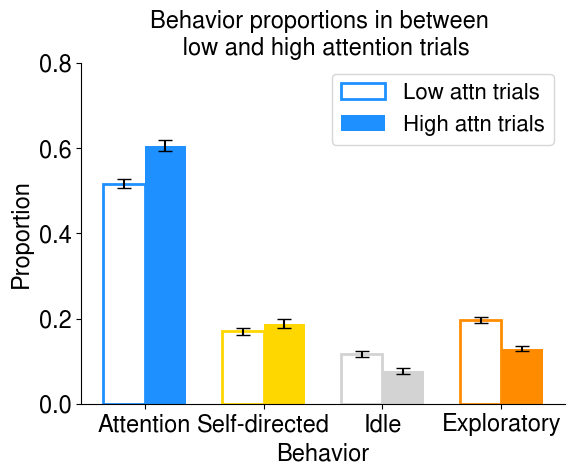

In [19]:
categories_label = [*categories_label_dict.keys()]
kept_beh_prop = get_beh_prop(all_kept_behavior_seg, categories_label)
filtered_beh_prop = get_beh_prop(all_filtered_behavior_seg, categories_label)

filtered_beh_prop_mean = np.mean(filtered_beh_prop, axis = 0)
filtered_beh_prop_se = np.std(filtered_beh_prop, axis = 0) / np.sqrt(len(filtered_beh_prop))

kept_beh_prop_mean = np.mean(kept_beh_prop, axis = 0)
kept_beh_prop_se = np.std(kept_beh_prop, axis = 0) / np.sqrt(len(kept_beh_prop))

colors_arr = ["dodgerblue", "gold", "lightgray", "darkorange"]
fig, ax = plt.subplots(figsize = (6, 5))

x = np.arange(1, 5)
width = 0.35
ax.bar(x - width/2, filtered_beh_prop_mean, width, yerr = filtered_beh_prop_se, 
       color = "white", edgecolor = colors_arr, capsize = 5, label = "Low attn trials", lw = 2)
ax.bar(x + width/2, kept_beh_prop_mean, width, yerr = kept_beh_prop_se, 
       color = colors_arr, capsize = 5, label = "High attn trials", lw = 2)

fontsize = 17
ax.set_xticks(np.arange(1, 5), [*categories_label_dict.values()], fontsize = fontsize)
ax.set_yticks(np.arange(0, .81, .2), np.round(np.arange(0, .81, .2), 1), fontsize = fontsize)

ax.legend(fontsize = fontsize - 1)

ax.set_xlabel("Behavior", fontsize = fontsize)
ax.set_ylabel("Proportion", fontsize = fontsize)

ax.set_title("Behavior proportions in between \n low and high attention trials", fontsize = fontsize)

plt.tight_layout()
sns.despine()

# plt.savefig(os.path.join(fig_pub_path, "behavior_proportion_after_filtering.svg"), format = "svg", dpi = 300)

In [ ]:
start_frame, end_frame = 240, 260

attn_prop_list = []
for i in all_kept_behavior_seg:
    attn_prop = len(np.where(i[200: 280] == 1)[0]) / 20
    attn_prop_list.append(attn_prop)

low_attn_trials = np.where((np.array(attn_prop_list) >= .1) & (np.array(attn_prop_list) <= .95))[0]
low_attn_seg = all_kept_behavior_seg[low_attn_trials, :]
low_attn_seg_shifted = all_kept_behavior_seg_shifted[low_attn_trials, :]
kept_beh_prop = get_beh_prop(low_attn_seg, categories_label, start_frame, end_frame)
kept_beh_prop_shifted = get_beh_prop(low_attn_seg_shifted, categories_label, start_frame, end_frame)

In [35]:
results = compare_arrays_with_fdr(kept_beh_prop, kept_beh_prop_shifted, 
                                  column_labels=[*categories_label_dict.values()])

Paired t-tests for each column:
------------------------------------------------------------
Attention: t=-3.730, p=0.0004, mean_diff=-0.1492
Self-directed: t=0.602, p=0.5496, mean_diff=0.0187
Idle: t=2.344, p=0.0222, mean_diff=0.0656
Exploratory: t=2.110, p=0.0388, mean_diff=0.0648

FDR-corrected results (α=0.05):
------------------------------------------------------------
Attention: p=0.0004, p_corrected=0.0017, **
Self-directed: p=0.5496, p_corrected=0.5496, ns
Idle: p=0.0222, p_corrected=0.0444, *
Exploratory: p=0.0388, p_corrected=0.0518, ns


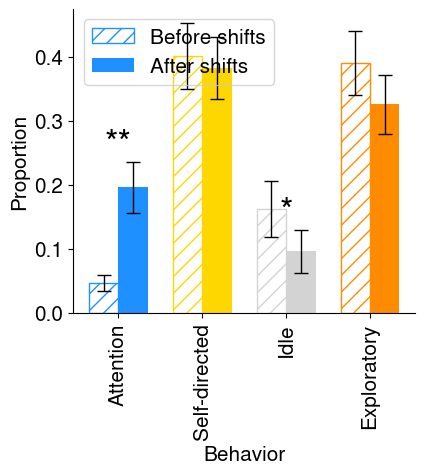

In [ ]:
beh_prop_mean = np.mean(kept_beh_prop, axis = 0)
beh_prop_se = np.std(kept_beh_prop, axis = 0) / np.sqrt(len(kept_beh_prop))

shift_beh_prop_mean = np.mean(kept_beh_prop_shifted, axis = 0)
shift_beh_prop_se = np.std(kept_beh_prop_shifted, axis = 0) / np.sqrt(len(kept_beh_prop_shifted))

fig, ax = plt.subplots(figsize = (4.5, 5))

fontsize = 15
x = np.arange(1, 5)
width = 0.35

ax.bar(x - width/2, beh_prop_mean, width,
       yerr = beh_prop_se, color = 'None', edgecolor = colors_arr,  
       capsize = 5, label = 'Before shifts', lw = 1, alpha = .99, 
       error_kw={'linewidth': 1, 'capthick': 1, "elinewidth": 1},
       hatch = '//')
ax.bar(x + width/2, shift_beh_prop_mean, width,
       yerr = shift_beh_prop_se, color = colors_arr, 
       error_kw={'linewidth': 1, 'capthick': 1, "elinewidth": 1},
       capsize = 5, label = 'After shifts', lw = 1)

p_values_corrected, rejected = results['p_corrected'], results['rejected']
for i, (p_corr, is_sig) in enumerate(zip(p_values_corrected, rejected)):
    if is_sig:
       if p_corr < 0.001:
              sig_str = "***"
       elif p_corr < 0.01:
              sig_str = "**"
       elif p_corr < 0.05:
              sig_str = "*"
       else:
              sig_str = "" 
              
       y_pos = shift_beh_prop_mean[i] + shift_beh_prop_se[i]
       ax.text(x[i], y_pos, sig_str, ha='center', va='bottom', fontsize=25)
    
ax.set_xticks(np.arange(1, 5), [*categories_label_dict.values()], fontsize = fontsize, rotation = 90)
ax.set_yticks(np.arange(0, .41, .1), np.round(np.arange(0, .41, .1), 1), fontsize = fontsize)

ax.set_xlabel("Behavior", fontsize = fontsize)
ax.set_ylabel("Proportion", fontsize = fontsize)

ax.legend(fontsize = fontsize)
plt.tight_layout()
sns.despine()

plt.savefig(os.path.join(fig_pub_path, "behavior_proportion_low_attn_trials.svg"), format = "svg", dpi = 300)